# Linda Vasquez proyecto de árbol de decisión

## 1. Carga de datos

In [1]:
import pandas as pd

ruta_datos = "https://breathecode.herokuapp.com/asset/internal-link?id=930&path=diabetes.csv"

datos = pd.read_csv(ruta_datos)

print(datos.head())

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  


## 2. EDA y división de datos

In [2]:
from sklearn.model_selection import train_test_split

print("Información del dataset:")
print(datos.info())
print("\nResumen estadístico:")
print(datos.describe())

caracteristicas = datos.drop(columns=["Outcome"])
objetivo = datos["Outcome"]

x_entrena, x_prueba, y_entrena, y_prueba = train_test_split(caracteristicas, objetivo, test_size=0.2, random_state=42)

Información del dataset:
<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None

Resumen estadístico:
       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   768.000000  768.000000     768.000000     768.000000  768.000000   
mean      3.845052  120.894531      69.105469  

## 3. Árbol de decisión

Precisión del árbol con Gini: 0.7467532467532467
Precisión del árbol con Entropía: 0.7207792207792207


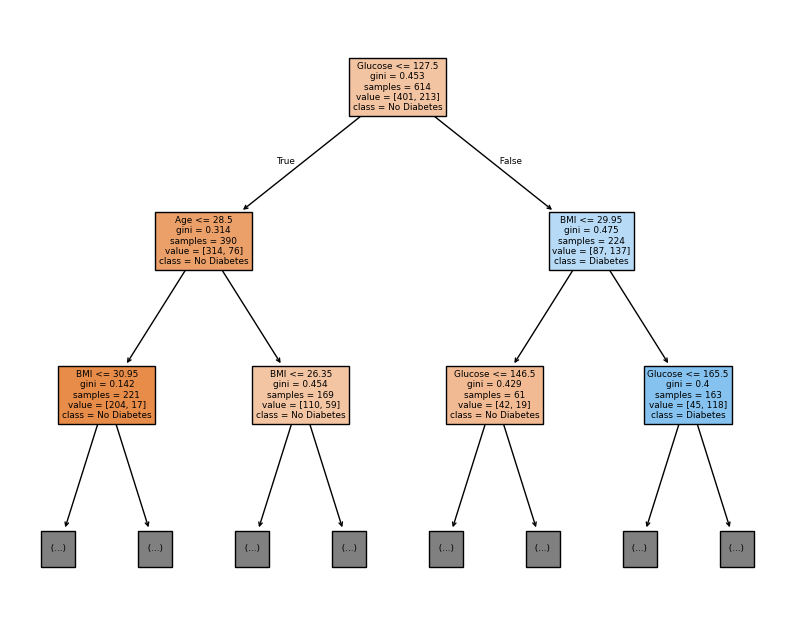

In [3]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
from sklearn import tree

# Creamos y entrenamos el modelo con criterio Gini
modelo_gini = DecisionTreeClassifier(criterion="gini", random_state=42)
modelo_gini.fit(x_entrena, y_entrena)

# ///// Criterio Entropía
modelo_entropia = DecisionTreeClassifier(criterion="entropy", random_state=42)
modelo_entropia.fit(x_entrena, y_entrena)

# Predecimos con ambos modelos
predicciones_gini = modelo_gini.predict(x_prueba)
predicciones_entropia = modelo_entropia.predict(x_prueba)

# Comparamos la precisión
precision_gini = accuracy_score(y_prueba, predicciones_gini)
precision_entropia = accuracy_score(y_prueba, predicciones_entropia)

print(f"Precisión del árbol con Gini: {precision_gini}")
print(f"Precisión del árbol con Entropía: {precision_entropia}")

plt.figure(figsize=(10,8))
tree.plot_tree(modelo_gini, max_depth=2, feature_names=list(caracteristicas.columns), class_names=["No Diabetes", "Diabetes"], filled=True)
plt.show()

## 4.Optimización del modelo

In [4]:
from sklearn.model_selection import GridSearchCV

parametros_a_probar = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 5, 10, 15],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

modelo_base = DecisionTreeClassifier(random_state=42)

#Búsqueda en cuadrícula (GridSearch)
busqueda_cuadricula = GridSearchCV(modelo_base, parametros_a_probar, cv=5, scoring='accuracy')

busqueda_cuadricula.fit(x_entrena, y_entrena)

# Se extrae el mejor modelo
mejor_modelo = busqueda_cuadricula.best_estimator_

# Prueba con los datos de prueba
predicciones_mejoradas = mejor_modelo.predict(x_prueba)
precision_mejorada = accuracy_score(y_prueba, predicciones_mejoradas)

print(f"Mejor combinación de hiperparámetros: {busqueda_cuadricula.best_params_}")
print(f"Nueva precisión optimizada: {precision_mejorada}")

Mejor combinación de hiperparámetros: {'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 2}
Nueva precisión optimizada: 0.7857142857142857


## 5. Almacenamiento

In [15]:
import pandas as pd
from pickle import dump

datos_entrenamiento = x_entrena.copy()
datos_entrenamiento["Outcome"] = y_entrena

datos_prueba = x_prueba.copy()
datos_prueba["Outcome"] = y_prueba

datos_entrenamiento.to_csv("../data/processed/clean_diabetes_train.csv", index=False)
datos_prueba.to_csv("../data/processed/clean_diabetes_test.csv", index=False)

print("¡Datos guardados, ve a data en github!")

nombre_archivo = "../models/arbol_decision_optimizado_42.sav"
dump(mejor_modelo, open(nombre_archivo, "wb"))

print(f"\nModelo guardado como {nombre_archivo}")

¡Datos guardados, ve a data en github!

Modelo guardado como ../models/arbol_decision_optimizado_42.sav
